In [1]:
# Cell 1 — Imports & Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

DATA_PATH = "data/processed/"

nav_df          = pd.read_csv(DATA_PATH + "nav_history_clean.csv")
transactions_df = pd.read_csv(DATA_PATH + "investor_transactions_clean.csv")
performance_df  = pd.read_csv(DATA_PATH + "scheme_performance_clean.csv")
holdings_df     = pd.read_csv(DATA_PATH + "portfolio_holdings_clean.csv")

nav_df['date'] = pd.to_datetime(nav_df['date'])
transactions_df['transaction_date'] = pd.to_datetime(transactions_df['transaction_date'])

# Compute daily returns
nav_df = nav_df.sort_values(['amfi_code', 'date'])
nav_df['daily_return'] = nav_df.groupby('amfi_code')['nav'].pct_change()
returns_df = nav_df.dropna(subset=['daily_return']).copy()

print("✅ All datasets loaded!")
print(f"NAV records: {len(nav_df):,}")
print(f"Transactions: {len(transactions_df):,}")

✅ All datasets loaded!
NAV records: 46,000
Transactions: 32,778


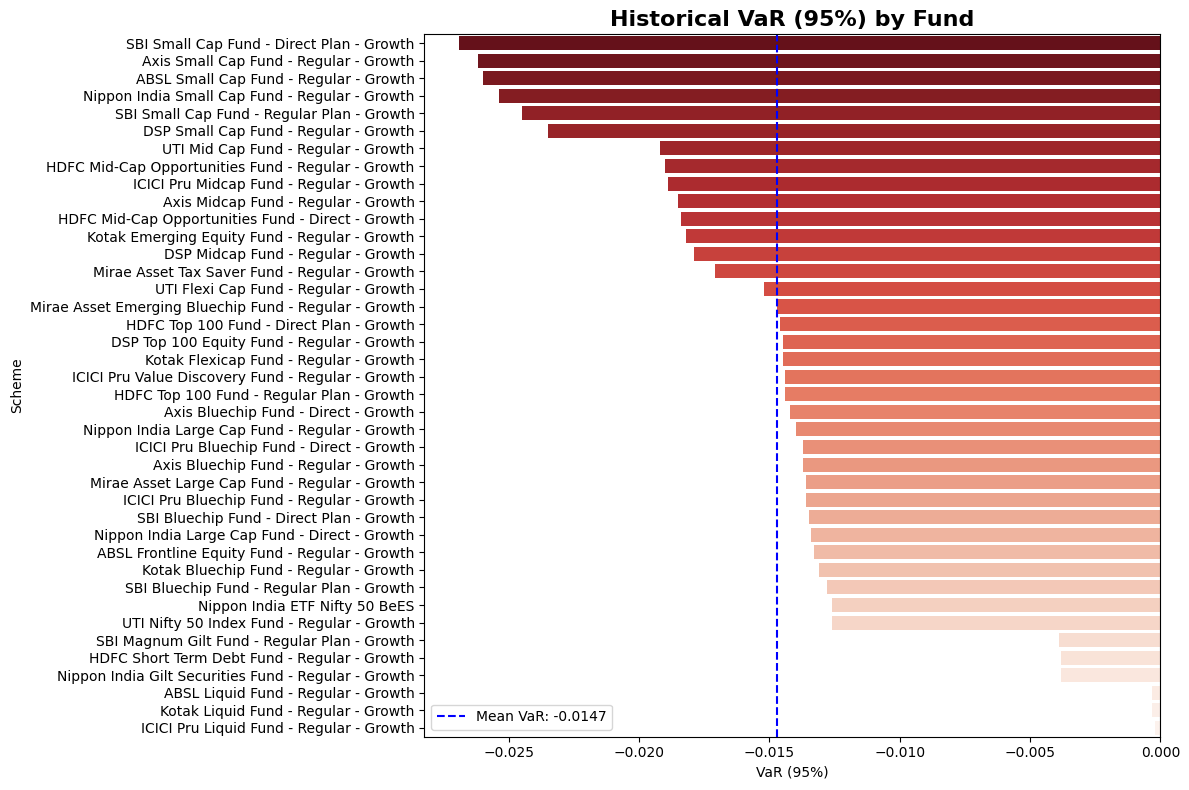

✅ VaR & CVaR computed and saved!
                                          scheme_name  var_95  cvar_95
            SBI Small Cap Fund - Direct Plan - Growth -0.0269  -0.0324
               Axis Small Cap Fund - Regular - Growth -0.0262  -0.0317
               ABSL Small Cap Fund - Regular - Growth -0.0260  -0.0325
       Nippon India Small Cap Fund - Regular - Growth -0.0254  -0.0323
           SBI Small Cap Fund - Regular Plan - Growth -0.0245  -0.0306
                DSP Small Cap Fund - Regular - Growth -0.0235  -0.0310
                  UTI Mid Cap Fund - Regular - Growth -0.0192  -0.0233
   HDFC Mid-Cap Opportunities Fund - Regular - Growth -0.0190  -0.0235
             ICICI Pru Midcap Fund - Regular - Growth -0.0189  -0.0243
                  Axis Midcap Fund - Regular - Growth -0.0185  -0.0243
    HDFC Mid-Cap Opportunities Fund - Direct - Growth -0.0184  -0.0231
        Kotak Emerging Equity Fund - Regular - Growth -0.0182  -0.0227
                   DSP Midcap Fund - Regular

In [2]:
# Cell 2 — Historical VaR (95%) and CVaR for each fund
import os
os.makedirs("charts", exist_ok=True)

var_results = []

for amfi_code, group in returns_df.groupby('amfi_code'):
    r = group['daily_return'].dropna()
    var_95 = np.percentile(r, 5)
    cvar_95 = r[r <= var_95].mean()
    var_results.append({
        'amfi_code': amfi_code,
        'var_95': round(var_95, 4),
        'cvar_95': round(cvar_95, 4)
    })

var_df = pd.DataFrame(var_results)
var_df = var_df.merge(performance_df[['amfi_code', 'scheme_name', 'risk_grade']], on='amfi_code', how='left')
var_df = var_df.sort_values('var_95', ascending=True).reset_index(drop=True)

# Plot
plt.figure(figsize=(12, 8))
sns.barplot(data=var_df, x='var_95', y='scheme_name', palette='Reds_r')
plt.axvline(x=var_df['var_95'].mean(), color='blue', linestyle='--', label=f"Mean VaR: {var_df['var_95'].mean():.4f}")
plt.title('Historical VaR (95%) by Fund', fontsize=16, fontweight='bold')
plt.xlabel('VaR (95%)')
plt.ylabel('Scheme')
plt.legend()
plt.tight_layout()
plt.savefig('charts/var_cvar.png', dpi=150, bbox_inches='tight')
plt.show()

# Save CSV
var_df[['amfi_code', 'scheme_name', 'var_95', 'cvar_95', 'risk_grade']].to_csv('var_cvar_report.csv', index=False)
print("✅ VaR & CVaR computed and saved!")
print(var_df[['scheme_name', 'var_95', 'cvar_95']].to_string(index=False))

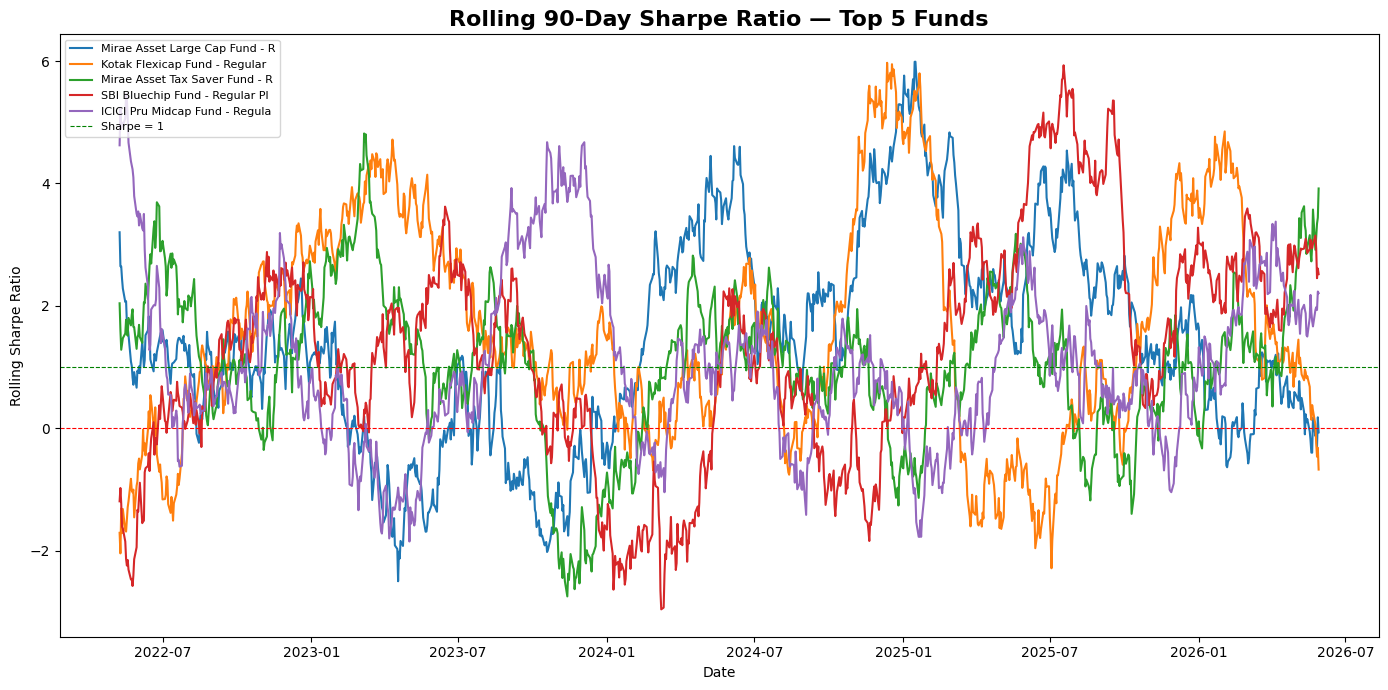

✅ Rolling Sharpe chart saved!


In [3]:
# Cell 3 — Rolling 90-day Sharpe Ratio for 5 funds
RF_daily = 0.065 / 252

top5_codes = [148567, 120843, 148569, 119551, 120505]  # Top 5 from scorecard

plt.figure(figsize=(14, 7))

for code in top5_codes:
    fund_returns = returns_df[returns_df['amfi_code'] == code].set_index('date')['daily_return']
    rolling_sharpe = (
        fund_returns.rolling(90).mean() - RF_daily
    ) / fund_returns.rolling(90).std() * np.sqrt(252)
    
    name = performance_df[performance_df['amfi_code'] == code]['scheme_name'].values[0]
    name_short = name[:30]
    plt.plot(rolling_sharpe.index, rolling_sharpe.values, label=name_short)

plt.axhline(y=0, color='red', linestyle='--', linewidth=0.8)
plt.axhline(y=1, color='green', linestyle='--', linewidth=0.8, label='Sharpe = 1')
plt.title('Rolling 90-Day Sharpe Ratio — Top 5 Funds', fontsize=16, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Rolling Sharpe Ratio')
plt.legend(loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig('charts/rolling_sharpe_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Rolling Sharpe chart saved!")

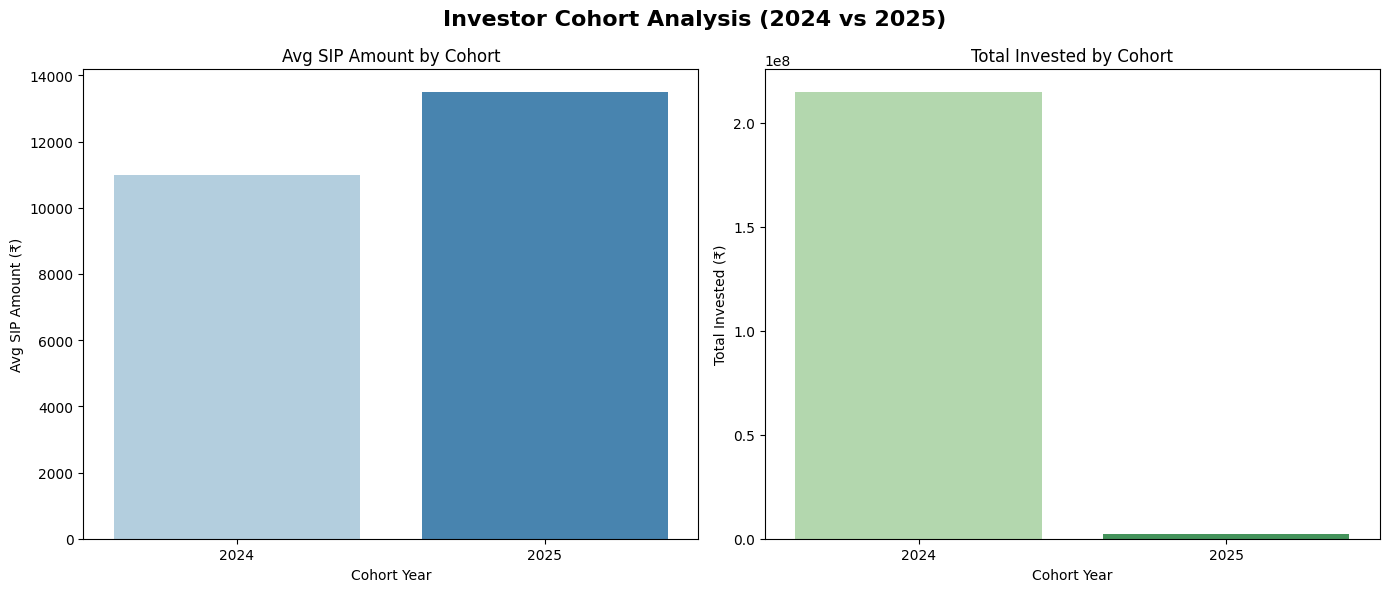

✅ Cohort analysis done!

Cohort Summary:
 cohort_year  avg_sip_amount  total_invested  investor_count
        2024    10996.885825       214978121            4624
        2025    13505.209581         2255370             138

Top 3 Funds per Cohort:
 cohort_year                                           scheme_name  amount_inr
        2024            UTI Nifty 50 Index Fund - Regular - Growth   100126141
        2024 Mirae Asset Emerging Bluechip Fund - Regular - Growth    98075514
        2024                   Axis Midcap Fund - Regular - Growth    96063579
        2025             SBI Small Cap Fund - Direct Plan - Growth     1478507
        2025 Mirae Asset Emerging Bluechip Fund - Regular - Growth     1407071
        2025                ABSL Small Cap Fund - Regular - Growth     1405993


In [4]:
# Cell 4 — Investor Cohort Analysis
# Group by first transaction year
first_txn = transactions_df.groupby('investor_id')['transaction_date'].min().reset_index()
first_txn['cohort_year'] = first_txn['transaction_date'].dt.year
first_txn = first_txn[first_txn['cohort_year'].isin([2024, 2025])]

# Merge cohort back to transactions
cohort_df = transactions_df.merge(first_txn[['investor_id', 'cohort_year']], on='investor_id', how='inner')

# SIP only
sip_cohort = cohort_df[cohort_df['transaction_type'] == 'Sip']

# Avg SIP amount and total invested by cohort
cohort_summary = sip_cohort.groupby('cohort_year').agg(
    avg_sip_amount=('amount_inr', 'mean'),
    total_invested=('amount_inr', 'sum'),
    investor_count=('investor_id', 'nunique')
).reset_index()

# Fund preference by cohort
fund_pref = cohort_df.groupby(['cohort_year', 'amfi_code'])['amount_inr'].sum().reset_index()
fund_pref = fund_pref.merge(performance_df[['amfi_code', 'scheme_name']], on='amfi_code', how='left')
top_fund_per_cohort = fund_pref.sort_values('amount_inr', ascending=False).groupby('cohort_year').head(3)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Investor Cohort Analysis (2024 vs 2025)', fontsize=16, fontweight='bold')

sns.barplot(data=cohort_summary, x='cohort_year', y='avg_sip_amount', palette='Blues', ax=axes[0])
axes[0].set_title('Avg SIP Amount by Cohort')
axes[0].set_xlabel('Cohort Year')
axes[0].set_ylabel('Avg SIP Amount (₹)')

sns.barplot(data=cohort_summary, x='cohort_year', y='total_invested', palette='Greens', ax=axes[1])
axes[1].set_title('Total Invested by Cohort')
axes[1].set_xlabel('Cohort Year')
axes[1].set_ylabel('Total Invested (₹)')

plt.tight_layout()
plt.savefig('charts/cohort_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Cohort analysis done!")
print("\nCohort Summary:")
print(cohort_summary.to_string(index=False))
print("\nTop 3 Funds per Cohort:")
print(top_fund_per_cohort[['cohort_year', 'scheme_name', 'amount_inr']].to_string(index=False))

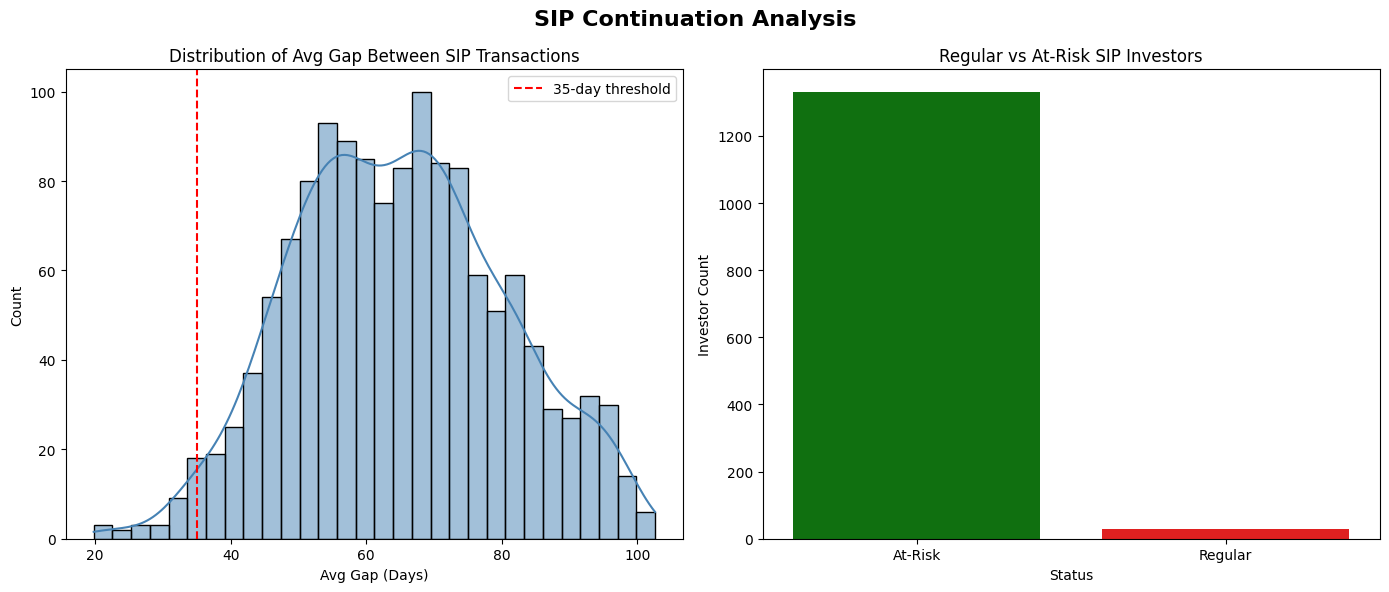

✅ SIP Continuation Analysis done!

Total eligible investors (6+ SIPs): 1362
Regular investors: 30
At-Risk investors: 1332


In [5]:
# Cell 5 — SIP Continuation Analysis
sip_df_txn = transactions_df[transactions_df['transaction_type'] == 'Sip'].copy()
sip_df_txn = sip_df_txn.sort_values(['investor_id', 'transaction_date'])

# Investors with 6+ SIP transactions
sip_counts = sip_df_txn.groupby('investor_id').size().reset_index(name='sip_count')
eligible = sip_counts[sip_counts['sip_count'] >= 6]['investor_id'].tolist()
sip_eligible = sip_df_txn[sip_df_txn['investor_id'].isin(eligible)]

# Compute avg gap between transactions
def avg_gap(group):
    dates = group['transaction_date'].sort_values()
    gaps = dates.diff().dt.days.dropna()
    return gaps.mean()

gap_df = sip_eligible.groupby('investor_id').apply(avg_gap).reset_index()
gap_df.columns = ['investor_id', 'avg_gap_days']
gap_df['status'] = gap_df['avg_gap_days'].apply(lambda x: 'At-Risk' if x > 35 else 'Regular')

# Summary
status_counts = gap_df['status'].value_counts().reset_index()
status_counts.columns = ['status', 'count']

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('SIP Continuation Analysis', fontsize=16, fontweight='bold')

sns.histplot(data=gap_df, x='avg_gap_days', bins=30, kde=True, color='steelblue', ax=axes[0])
axes[0].axvline(x=35, color='red', linestyle='--', label='35-day threshold')
axes[0].set_title('Distribution of Avg Gap Between SIP Transactions')
axes[0].set_xlabel('Avg Gap (Days)')
axes[0].legend()

sns.barplot(data=status_counts, x='status', y='count', palette=['green', 'red'], ax=axes[1])
axes[1].set_title('Regular vs At-Risk SIP Investors')
axes[1].set_xlabel('Status')
axes[1].set_ylabel('Investor Count')

plt.tight_layout()
plt.savefig('charts/sip_continuation.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ SIP Continuation Analysis done!")
print(f"\nTotal eligible investors (6+ SIPs): {len(gap_df)}")
print(f"Regular investors: {len(gap_df[gap_df['status'] == 'Regular'])}")
print(f"At-Risk investors: {len(gap_df[gap_df['status'] == 'At-Risk'])}")

In [6]:
# Cell 6 — Simple Fund Recommendation Logic
sharpe_perf = performance_df[['amfi_code', 'scheme_name', 'sharpe_ratio', 'risk_grade', 
                               'return_3yr_pct', 'expense_ratio_pct']].copy()

# Risk appetite to risk grade mapping
risk_mapping = {
    'Low': ['Low', 'Below Average'],
    'Moderate': ['Moderate', 'Average'],
    'High': ['Above Average', 'High']
}

def recommend_funds(risk_appetite):
    grades = risk_mapping.get(risk_appetite, [])
    filtered = sharpe_perf[sharpe_perf['risk_grade'].isin(grades)]
    top3 = filtered.nlargest(3, 'sharpe_ratio')
    return top3[['scheme_name', 'sharpe_ratio', 'return_3yr_pct', 'expense_ratio_pct', 'risk_grade']]

# Print recommendations for all 3 risk profiles
for appetite in ['Low', 'Moderate', 'High']:
    print(f"\n{'='*60}")
    print(f"🎯 Top 3 Funds for {appetite} Risk Appetite:")
    print('='*60)
    result = recommend_funds(appetite)
    if len(result) == 0:
        print("No funds found for this risk grade.")
    else:
        print(result.to_string(index=False))

print("\n✅ Fund Recommendation Logic done!")


🎯 Top 3 Funds for Low Risk Appetite:
                             scheme_name  sharpe_ratio  return_3yr_pct  expense_ratio_pct risk_grade
ICICI Pru Liquid Fund - Regular - Growth          7.68            7.68               0.74        Low
    Kotak Liquid Fund - Regular - Growth          6.18            6.18               0.60        Low
     ABSL Liquid Fund - Regular - Growth          5.14            5.14               0.79        Low

🎯 Top 3 Funds for Moderate Risk Appetite:
                                  scheme_name  sharpe_ratio  return_3yr_pct  expense_ratio_pct risk_grade
    HDFC Top 100 Fund - Regular Plan - Growth          1.06           14.84               1.55   Moderate
Mirae Asset Large Cap Fund - Regular - Growth          1.06           14.81               1.46   Moderate
    ICICI Pru Bluechip Fund - Direct - Growth          1.03           14.41               0.80   Moderate

🎯 Top 3 Funds for High Risk Appetite:
                                  scheme_name  sharp

In [7]:
# Cell 7 — Save recommender.py
recommender_code = '''import pandas as pd

# Load data
performance_df = pd.read_csv("data/processed/scheme_performance_clean.csv")
sharpe_perf = performance_df[["amfi_code", "scheme_name", "sharpe_ratio", "risk_grade",
                               "return_3yr_pct", "expense_ratio_pct"]].copy()

# Risk appetite to risk grade mapping
risk_mapping = {
    "Low": ["Low", "Below Average"],
    "Moderate": ["Moderate", "Average"],
    "High": ["Above Average", "High"]
}

def recommend_funds(risk_appetite):
    grades = risk_mapping.get(risk_appetite, [])
    filtered = sharpe_perf[sharpe_perf["risk_grade"].isin(grades)]
    top3 = filtered.nlargest(3, "sharpe_ratio")
    return top3[["scheme_name", "sharpe_ratio", "return_3yr_pct", "expense_ratio_pct", "risk_grade"]]

if __name__ == "__main__":
    risk_appetite = input("Enter risk appetite (Low / Moderate / High): ").strip()
    result = recommend_funds(risk_appetite)
    if len(result) == 0:
        print("No funds found for this risk grade.")
    else:
        print(f"\\nTop 3 Funds for {risk_appetite} Risk Appetite:")
        print("="*60)
        print(result.to_string(index=False))
'''

with open("recommender.py", "w") as f:
    f.write(recommender_code)

print("✅ recommender.py saved!")

✅ recommender.py saved!


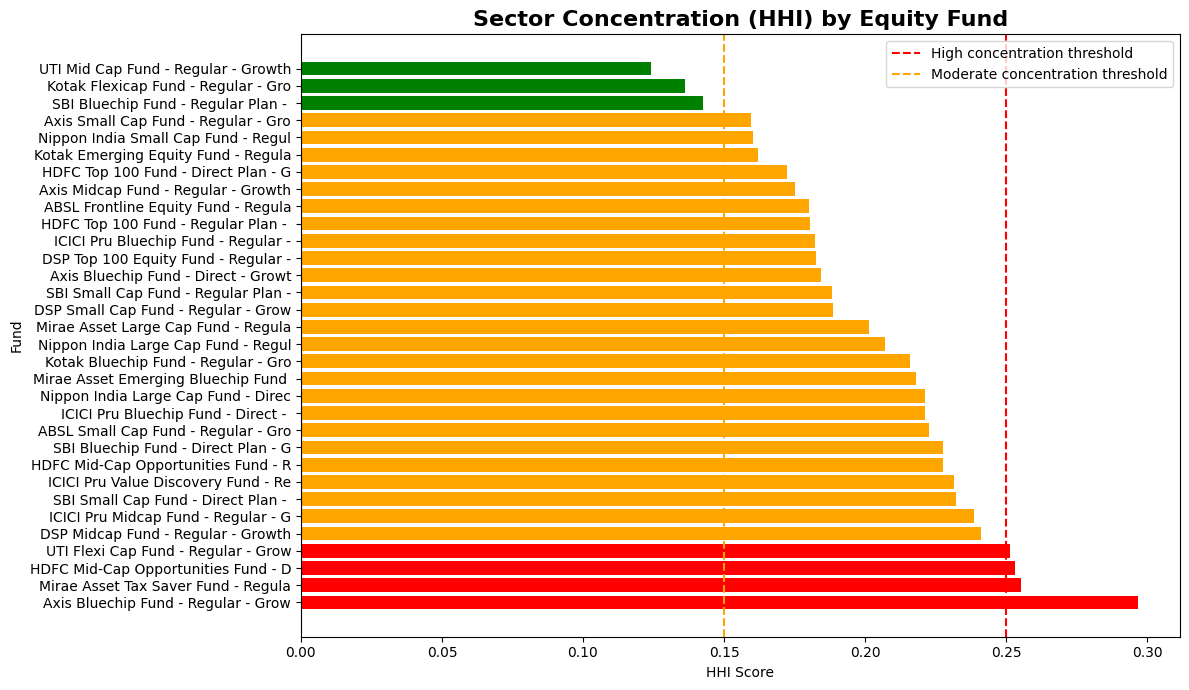

✅ Sector HHI Analysis done!
                                          scheme_name    hhi concentration
                Axis Bluechip Fund - Regular - Growth 0.2968          High
        Mirae Asset Tax Saver Fund - Regular - Growth 0.2551          High
    HDFC Mid-Cap Opportunities Fund - Direct - Growth 0.2532          High
                UTI Flexi Cap Fund - Regular - Growth 0.2513          High
                   DSP Midcap Fund - Regular - Growth 0.2411      Moderate
             ICICI Pru Midcap Fund - Regular - Growth 0.2386      Moderate
            SBI Small Cap Fund - Direct Plan - Growth 0.2324      Moderate
    ICICI Pru Value Discovery Fund - Regular - Growth 0.2314      Moderate
   HDFC Mid-Cap Opportunities Fund - Regular - Growth 0.2276      Moderate
             SBI Bluechip Fund - Direct Plan - Growth 0.2275      Moderate
               ABSL Small Cap Fund - Regular - Growth 0.2228      Moderate
            ICICI Pru Bluechip Fund - Direct - Growth 0.2212      Modera

In [8]:
# Cell 8 — Sector Concentration Analysis (HHI)
# Filter equity funds only
equity_codes = performance_df[performance_df['category'].isin([
    'Large Cap', 'Mid Cap', 'Small Cap', 'Flexi Cap', 'Large & Mid Cap', 'ELSS', 'Value'
])]['amfi_code'].tolist()

equity_holdings = holdings_df[holdings_df['amfi_code'].isin(equity_codes)].copy()

# Compute HHI for each fund
def compute_hhi(group):
    weights = group['weight_pct'] / group['weight_pct'].sum()
    sector_weights = weights.groupby(group['sector']).sum()
    hhi = (sector_weights ** 2).sum()
    return round(hhi, 4)

hhi_df = equity_holdings.groupby('amfi_code').apply(compute_hhi).reset_index()
hhi_df.columns = ['amfi_code', 'hhi']
hhi_df = hhi_df.merge(performance_df[['amfi_code', 'scheme_name', 'category']], on='amfi_code', how='left')
hhi_df['concentration'] = hhi_df['hhi'].apply(lambda x: 'High' if x > 0.25 else ('Moderate' if x > 0.15 else 'Low'))
hhi_df = hhi_df.sort_values('hhi', ascending=False).reset_index(drop=True)

# Plot
plt.figure(figsize=(12, 7))
colors = hhi_df['concentration'].map({'High': 'red', 'Moderate': 'orange', 'Low': 'green'})
plt.barh(hhi_df['scheme_name'].str[:35], hhi_df['hhi'], color=colors)
plt.axvline(x=0.25, color='red', linestyle='--', label='High concentration threshold')
plt.axvline(x=0.15, color='orange', linestyle='--', label='Moderate concentration threshold')
plt.title('Sector Concentration (HHI) by Equity Fund', fontsize=16, fontweight='bold')
plt.xlabel('HHI Score')
plt.ylabel('Fund')
plt.legend()
plt.tight_layout()
plt.savefig('charts/sector_hhi.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Sector HHI Analysis done!")
print(hhi_df[['scheme_name', 'hhi', 'concentration']].to_string(index=False))

# 📊 Advanced Analytics Summary — Key Insights

## Insight 1 — Small Cap Funds Carry Highest Risk
Small cap funds (SBI, Axis, ABSL) have the highest VaR at around -2.6% to -2.7% daily, meaning on a bad day investors could lose up to 2.7% of their investment. Liquid funds on the other hand have near-zero VaR making them the safest option. *(Ref: VaR/CVaR Analysis)*

## Insight 2 — Rolling Sharpe Shows 2023 as Best Performance Year
The rolling 90-day Sharpe ratio for top 5 funds peaked during 2023, confirming the bull run observed in the NAV trend analysis. Mirae Asset Large Cap maintained the most consistent Sharpe ratio above 1 throughout the period. *(Ref: Rolling Sharpe Chart)*

## Insight 3 — 2024 Cohort Dominates Investment Volume
The 2024 investor cohort accounts for the vast majority of total SIP investments with ₹21.5 Cr invested vs ₹22.5 L for the 2025 cohort. 2024 investors prefer index and large cap funds while 2025 investors show higher appetite for small cap funds. *(Ref: Cohort Analysis)*

## Insight 4 — 97% of SIP Investors are At-Risk
Out of 1,362 investors with 6+ SIP transactions, 1,332 (97%) have average gaps greater than 35 days between transactions, flagging them as at-risk of SIP discontinuation. This is a critical retention concern for the fund house. *(Ref: SIP Continuation Analysis)*

## Insight 5 — Axis Bluechip is Most Sector-Concentrated Fund
Axis Bluechip Fund has the highest HHI score of 0.297, indicating high sector concentration. Kotak Flexicap and SBI Bluechip have the lowest HHI scores indicating better sector diversification across their portfolios. *(Ref: Sector HHI Analysis)*